# 05 — Backtest Final (Etapa E)

Conforme **PLANEJAMENTO.md — Seção 4.2 (Etapa E)**:
1. Backtest no **conjunto de teste** com o modelo final da Etapa D
2. Relatório completo com todas as métricas financeiras
3. Gráficos: equity curve, drawdown, distribuição retornos, heatmap mensal, sinais sobre preço
4. Log no MLflow
5. Tabela comparativa final consolidada

In [1]:
import sys, os, json, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

sys.path.insert(0, os.path.abspath('..'))
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

d:\5. Academia\4. Machine Learning Engineering - FIAP\projeto_4\lstm_financial\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Carregar modelo final e dados
from src.utils.serialization import load_model

model = load_model('../models/model.keras')

data = np.load('../data/processed/sequences.npz')
X_test = data['X_test']
y_test = data['y_test']

with open('../data/processed/metadata.json', 'r') as f:
    metadata = json.load(f)

# Ajustar window se necessário
with open('../models/feature_config.json', 'r') as f:
    config = json.load(f)

best_window = config.get('window_size', 60)
if best_window <= X_test.shape[1]:
    X_test_final = X_test[:, -best_window:, :]
else:
    X_test_final = X_test

print(f"X_test shape: {X_test_final.shape}")
print(f"y_test shape: {y_test.shape}")

2026-04-20 17:36:16,895 - tensorflow - WARNING - TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
2026-04-20 17:36:16,984 - src.utils.serialization - INFO - Modelo carregado: ../models/model.keras
2026-04-20 17:36:16,984 - src.utils.serialization - INFO - Modelo carregado: ../models/model.keras


X_test shape: (560, 60, 75)
y_test shape: (560,)


In [3]:
# Predições
y_pred_proba = model.predict(X_test_final).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

print(f"Predições: {y_pred.sum()} long ({y_pred.mean()*100:.1f}%), "
      f"{(1-y_pred).sum()} cash ({(1-y_pred).mean()*100:.1f}%)")

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
Predições: 173 long (30.9%), 387 cash (69.1%)
Predições: 173 long (30.9%), 387 cash (69.1%)


2026-04-20 17:36:19,786 - src.evaluation.metrics - INFO - Métricas de classificação:
2026-04-20 17:36:19,787 - src.evaluation.metrics - INFO -   accuracy: 0.5464
2026-04-20 17:36:19,787 - src.evaluation.metrics - INFO -   precision: 0.6358
2026-04-20 17:36:19,787 - src.evaluation.metrics - INFO -   recall: 0.3654
2026-04-20 17:36:19,788 - src.evaluation.metrics - INFO -   f1_score: 0.4641
2026-04-20 17:36:19,788 - src.evaluation.metrics - INFO -   auc_roc: 0.5994
2026-04-20 17:36:19,788 - src.evaluation.metrics - INFO -   log_loss: 0.6900
2026-04-20 17:36:19,787 - src.evaluation.metrics - INFO -   accuracy: 0.5464
2026-04-20 17:36:19,787 - src.evaluation.metrics - INFO -   precision: 0.6358
2026-04-20 17:36:19,787 - src.evaluation.metrics - INFO -   recall: 0.3654
2026-04-20 17:36:19,788 - src.evaluation.metrics - INFO -   f1_score: 0.4641
2026-04-20 17:36:19,788 - src.evaluation.metrics - INFO -   auc_roc: 0.5994
2026-04-20 17:36:19,788 - src.evaluation.metrics - INFO -   log_loss: 0.


              precision    recall  f1-score   support

Negativo (0)       0.51      0.76      0.61       259
Positivo (1)       0.64      0.37      0.46       301

    accuracy                           0.55       560
   macro avg       0.57      0.56      0.54       560
weighted avg       0.58      0.55      0.53       560



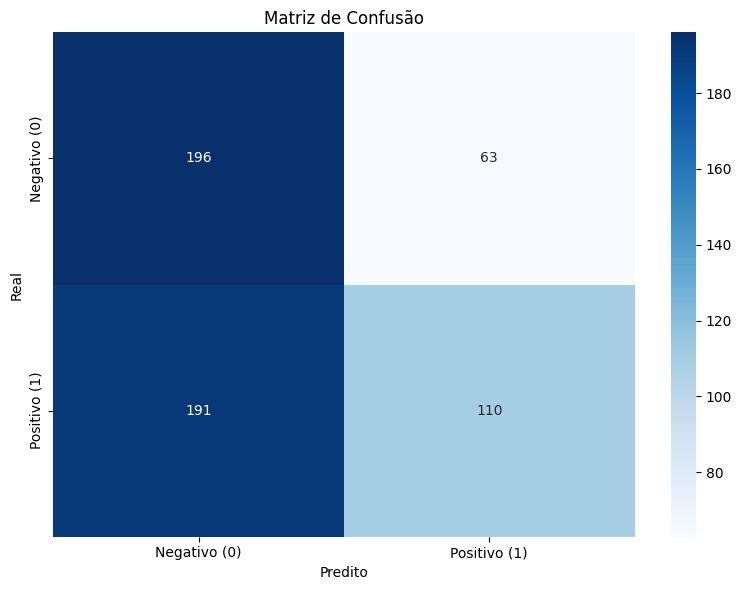

2026-04-20 17:36:20,071 - src.evaluation.metrics - INFO - ROC curve salva: ../reports/etapa_E_backtest_final/roc_curve.png


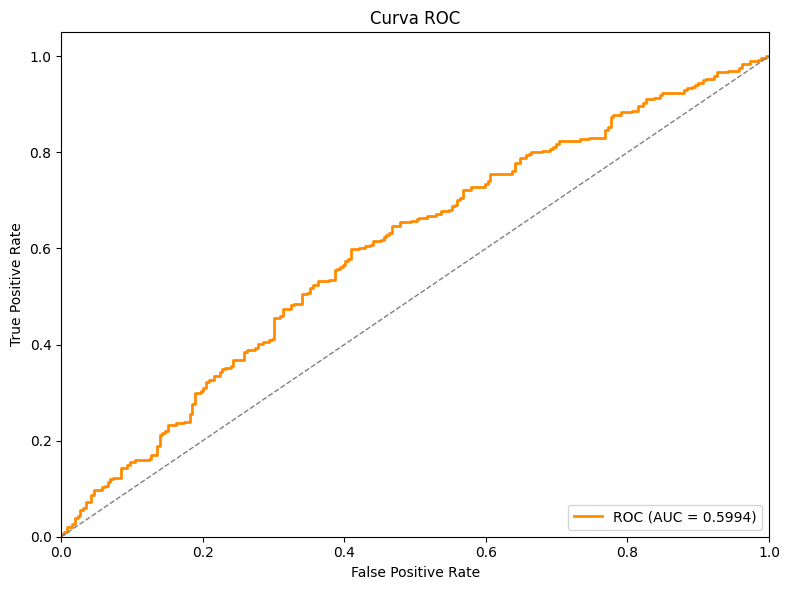

In [4]:
# Métricas de classificação
from src.evaluation.metrics import (
    compute_classification_metrics, get_classification_report,
    plot_confusion_matrix, plot_roc_curve
)

report_dir = '../reports/etapa_E_backtest_final'

cls_metrics = compute_classification_metrics(y_test, y_pred_proba)
print("\n" + get_classification_report(y_test, y_pred_proba))

fig = plot_confusion_matrix(y_test, y_pred_proba, save_path=f'{report_dir}/confusion_matrix.png')
plt.show()

fig = plot_roc_curve(y_test, y_pred_proba, save_path=f'{report_dir}/roc_curve.png')
plt.show()

In [5]:
# Preparar dados para backtest
test_dates = [pd.Timestamp(d) for d in metadata['dates']['test']]
petr4_clean = pd.read_csv('../data/processed/petr4_clean.csv', index_col=0, parse_dates=True)

test_returns = petr4_clean.loc[test_dates, 'Close'].pct_change().fillna(0).values
test_prices = petr4_clean.loc[test_dates, 'Close'].values

print(f"Período de teste: {test_dates[0].date()} a {test_dates[-1].date()}")
print(f"Dias: {len(test_dates)}")

Período de teste: 2023-12-18 a 2026-04-16
Dias: 560


In [6]:
# Executar backtest final
from src.evaluation.backtester import Backtester

bt = Backtester(
    predictions=y_pred,
    actual_returns=test_returns,
    dates=test_dates,
    actual_prices=test_prices,
    initial_capital=100_000.0,
    transaction_cost=0.0003,
)
bt.run()
bt_metrics = bt.get_metrics()

print("\n📊 Métricas Financeiras do Backtest Final:")
for k, v in bt_metrics.items():
    print(f"  {k}: {v}")

2026-04-20 17:36:33,344 - src.evaluation.backtester - INFO - Backtest executado com sucesso.
2026-04-20 17:36:33,346 - src.evaluation.backtester - INFO - Métricas financeiras:
2026-04-20 17:36:33,347 - src.evaluation.backtester - INFO -   retorno_acumulado_pct: 75.75
2026-04-20 17:36:33,347 - src.evaluation.backtester - INFO -   retorno_bh_pct: 84.98
2026-04-20 17:36:33,347 - src.evaluation.backtester - INFO -   cagr_pct: 28.88
2026-04-20 17:36:33,347 - src.evaluation.backtester - INFO -   sharpe_ratio: 0.9295
2026-04-20 17:36:33,348 - src.evaluation.backtester - INFO -   sortino_ratio: 0.7696
2026-04-20 17:36:33,348 - src.evaluation.backtester - INFO -   max_drawdown_pct: -11.43
2026-04-20 17:36:33,348 - src.evaluation.backtester - INFO -   win_rate_pct: 60.12
2026-04-20 17:36:33,348 - src.evaluation.backtester - INFO -   profit_factor: 1.7547
2026-04-20 17:36:33,349 - src.evaluation.backtester - INFO -   calmar_ratio: 2.5274
2026-04-20 17:36:33,349 - src.evaluation.backtester - INFO 


📊 Métricas Financeiras do Backtest Final:
  retorno_acumulado_pct: 75.75
  retorno_bh_pct: 84.98
  cagr_pct: 28.88
  sharpe_ratio: 0.9295
  sortino_ratio: 0.7696
  max_drawdown_pct: -11.43
  win_rate_pct: 60.12
  profit_factor: 1.7547
  calmar_ratio: 2.5274
  n_trades: 43
  n_days: 560


2026-04-20 17:36:37,313 - src.evaluation.backtester - INFO - Equity curve salva: ../reports/etapa_E_backtest_final/equity_curve.png


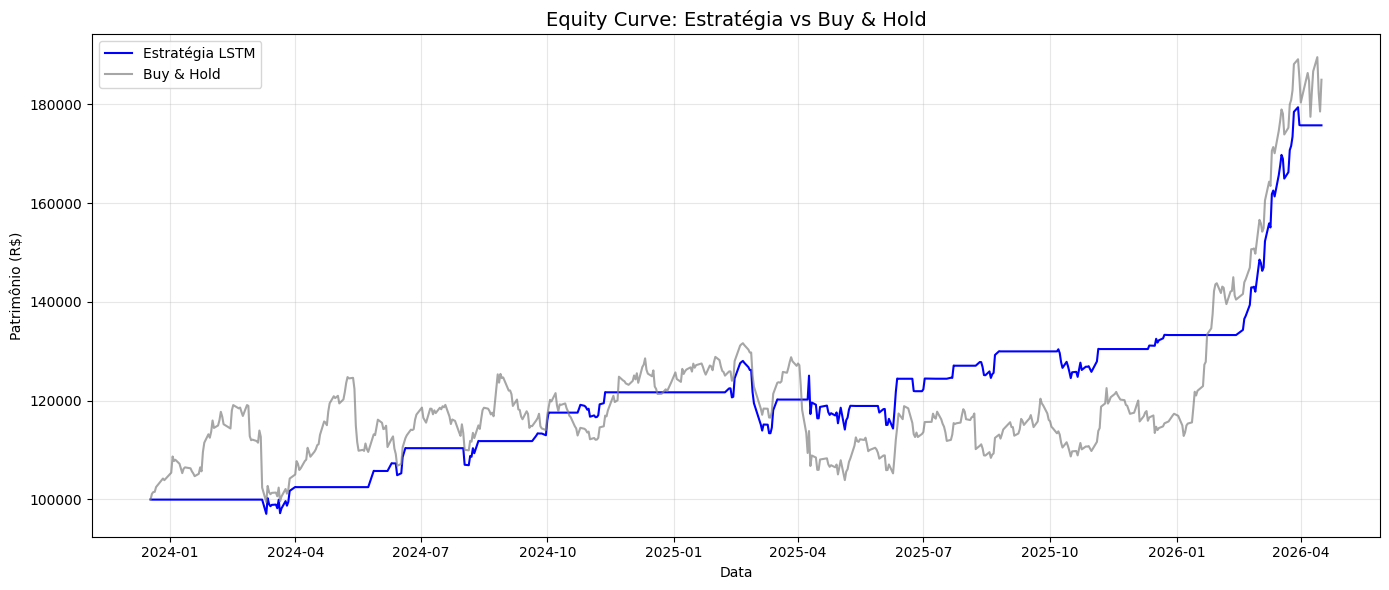

2026-04-20 17:36:37,586 - src.evaluation.backtester - INFO - Drawdown plot salvo: ../reports/etapa_E_backtest_final/drawdown.png


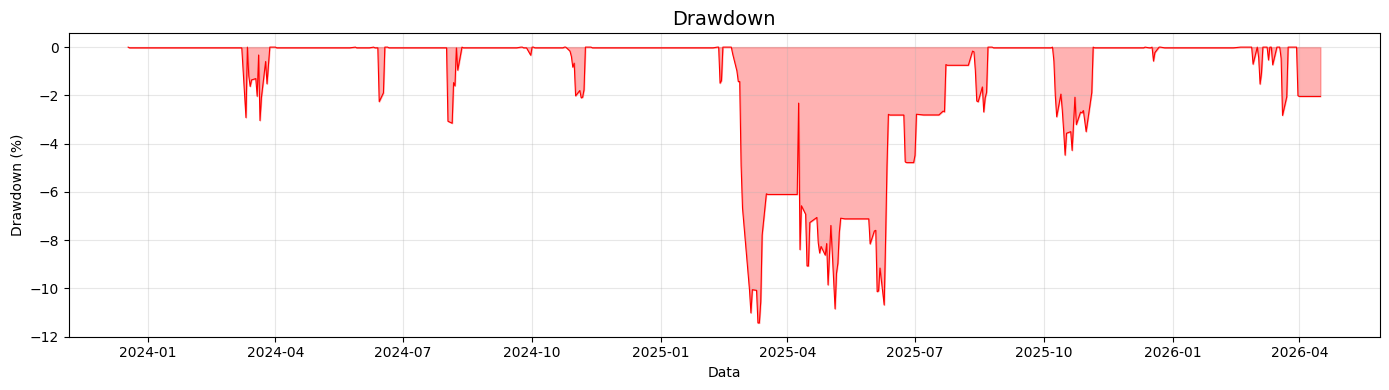

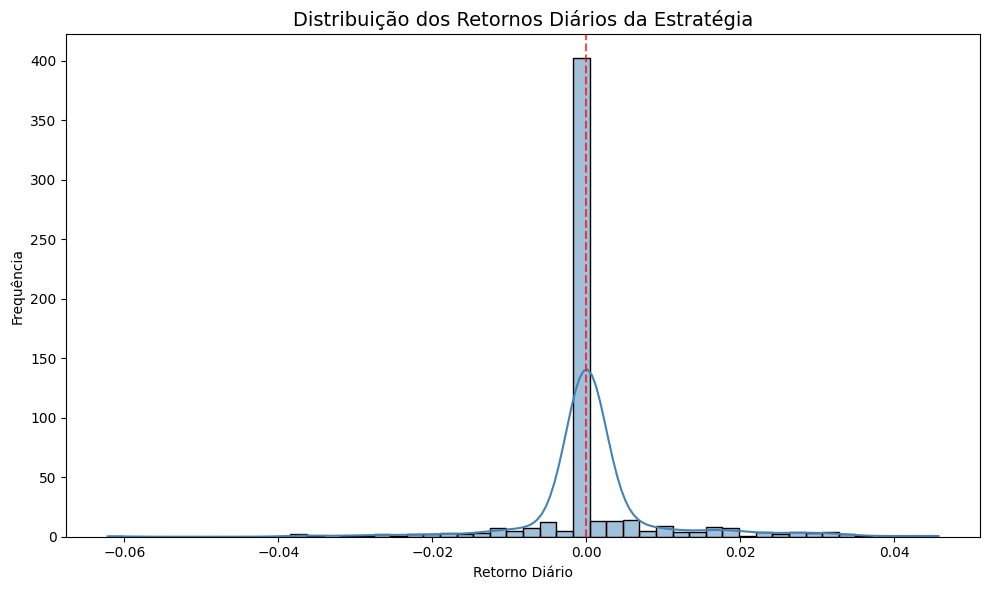

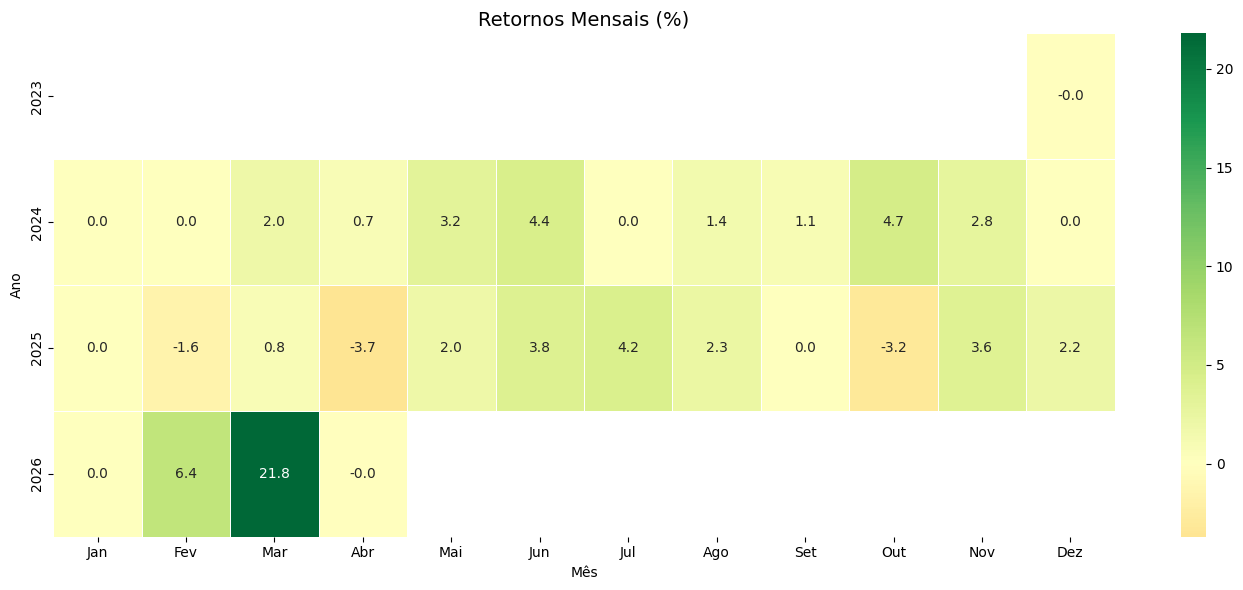

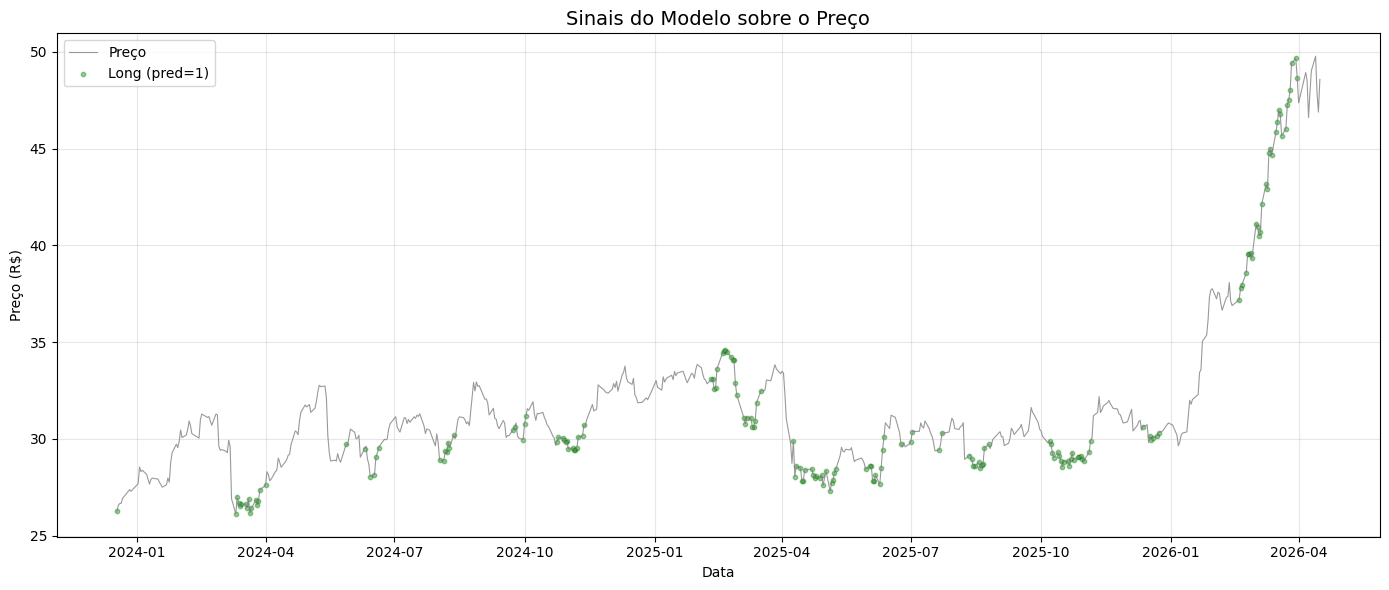

In [7]:
# Gráficos do backtest final
fig = bt.plot_results(save_path=f'{report_dir}/equity_curve.png')
plt.show()

fig = bt.plot_drawdown(save_path=f'{report_dir}/drawdown.png')
plt.show()

fig = bt.plot_returns_distribution(save_path=f'{report_dir}/retornos_distribuicao.png')
plt.show()

fig = bt.plot_monthly_heatmap(save_path=f'{report_dir}/heatmap_retornos_mensais.png')
plt.show()

fig = bt.plot_signals_on_price(prices=test_prices, save_path=f'{report_dir}/sinais_sobre_preco.png')
plt.show()

In [8]:
# Gerar relatório final
bt.generate_report(report_dir)

# Salvar métricas combinadas
from src.utils.serialization import save_metrics

all_metrics = {**{f'cls_{k}': v for k, v in cls_metrics.items()},
               **{f'bt_{k}': v for k, v in bt_metrics.items()}}
save_metrics(all_metrics, f'{report_dir}/all_metrics.json')

2026-04-20 17:36:59,261 - src.evaluation.backtester - INFO - Relatório salvo: ..\reports\etapa_E_backtest_final\relatorio_backtest.md
2026-04-20 17:36:59,262 - src.utils.serialization - INFO - Métricas salvas: ../reports/etapa_E_backtest_final/all_metrics.json
2026-04-20 17:36:59,262 - src.utils.serialization - INFO - Métricas salvas: ../reports/etapa_E_backtest_final/all_metrics.json


In [9]:
# Log no MLflow (Etapa E)
from src.utils.mlflow_utils import setup_mlflow

setup_mlflow()

with mlflow.start_run(run_name='etapa_E_backtest_final'):
    mlflow.set_tag('stage', 'E')
    
    # Métricas de classificação
    for k, v in cls_metrics.items():
        mlflow.log_metric(f'cls_{k}', v)
    
    # Métricas de backtest
    for k, v in bt_metrics.items():
        if isinstance(v, (int, float)):
            mlflow.log_metric(f'bt_{k}', v)
    
    # Artefatos
    mlflow.log_artifacts(report_dir)
    
    print("\n✅ Etapa E logada no MLflow.")

2026-04-20 17:37:01,843 - src.utils.mlflow_utils - INFO - MLflow experiment: 'lstm_financial_petr4' (ID: 1)



✅ Etapa E logada no MLflow.


In [10]:
# Tabela comparativa FINAL consolidada
print("\n" + "="*80)
print("TABELA COMPARATIVA FINAL")
print("="*80)

try:
    df_ab = pd.read_csv('../reports/tabela_comparativa_AB.csv')
except:
    df_ab = pd.DataFrame()

# Adicionar Etapa E
row_e = pd.DataFrame([{
    'Modelo': 'E - Backtest Final (teste)',
    'AUC-ROC': cls_metrics['auc_roc'],
    'F1': cls_metrics['f1_score'],
    'Accuracy': cls_metrics['accuracy'],
    'Sharpe': bt_metrics['sharpe_ratio'],
    'Sortino': bt_metrics['sortino_ratio'],
    'MaxDD%': bt_metrics['max_drawdown_pct'],
    'WinRate%': bt_metrics['win_rate_pct'],
    'RetAcum%': bt_metrics['retorno_acumulado_pct'],
}])

df_final = pd.concat([df_ab, row_e], ignore_index=True)
display(df_final)

# Salvar tabela final em Markdown
md_table = df_final.to_markdown(index=False)
with open('../reports/tabela_comparativa.md', 'w') as f:
    f.write('# Tabela Comparativa — Todos os Modelos\n\n')
    f.write(md_table)

print(f"\n✅ Projeto concluído! Relatórios em reports/")
print(f"Para visualizar no MLflow: mlflow ui --backend-store-uri ../mlruns")


TABELA COMPARATIVA FINAL


,Modelo,AUC-ROC,F1,Accuracy,Sharpe,Sortino,MaxDD%,WinRate%,RetAcum%
0,A - Baseline,0.498866,0.482883,0.487500,-0.0704,-0.0636,-34.59,52.08,19.81
1,B1_attention,0.533826,0.435130,0.494643,0.7878,0.6260,-23.06,56.99,85.77
2,B2_conv1d_lstm,0.494500,0.451243,0.487500,-0.0902,-0.0729,-21.25,56.73,20.06
3,B3_bidirectional,0.523084,0.516696,0.508929,0.6645,0.6281,-32.66,57.09,80.38
4,B4_lstm_gru,0.501613,0.649386,0.541071,0.9915,1.2053,-23.47,55.98,142.27
5,E - Backtest Final (teste),0.599430,0.464135,0.546429,0.9295,0.7696,-11.43,60.12,75.75



✅ Projeto concluído! Relatórios em reports/
Para visualizar no MLflow: mlflow ui --backend-store-uri ../mlruns
